# 01. EDA

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')
from preprocessing import load_data, clean_data, create_features, get_audio_features, save_processed_data

## 1. Подгрузка датасета

In [2]:
DATA_RAW = '../data/raw/spotify-tracks-dataset.csv'
DATA_PROCESSED = '../data/processed/spotify_processed.csv'
os.makedirs(os.path.dirname(DATA_PROCESSED), exist_ok=True)
os.makedirs('../report/images', exist_ok=True)

df = load_data(DATA_RAW)
print(f'{df.shape[0]} трека, {df.shape[1]} фичи')

114000 трека, 22 фичи


## 2. Очистка данных

In [3]:
df = clean_data(df)
print(f'{df.shape}')

Найдено 3 пропусков
(114000, 22)


## 3. Визуализация популярности

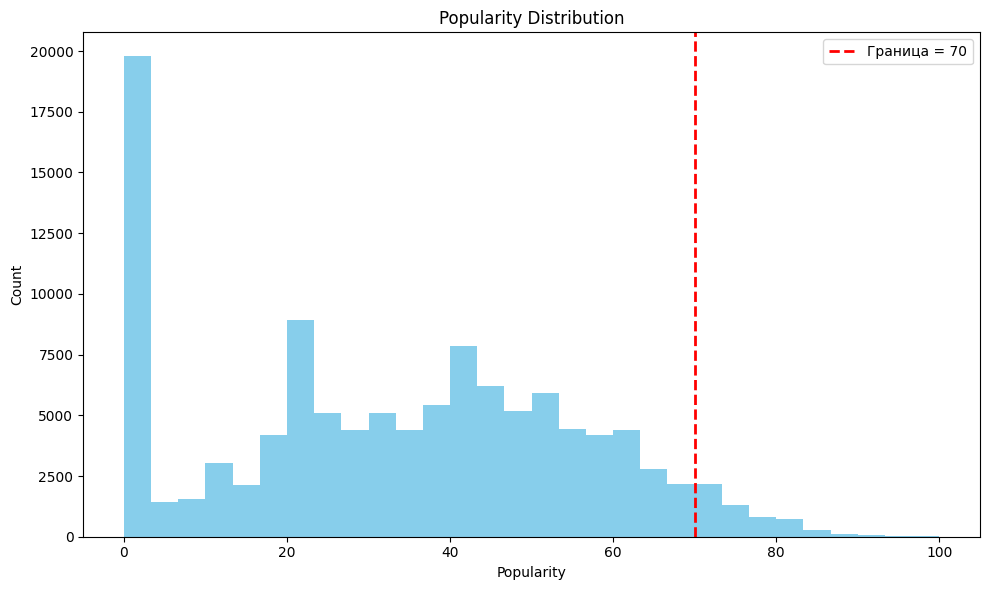

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=30, color='skyblue')
plt.axvline(70, color='red', linestyle='--', linewidth=2, label='Граница = 70')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../report/images/01_dist.png', dpi=300)
plt.show()

# Смомтря на данные графики можно понять, что значения популярности в районе >= 70 довольно редки и можно предположить, что оптимальнее всего будет рассматривать как раз-таки треки с таким показателем, как популярные.

## 4. Добавление новых фич

In [5]:
df = create_features(df)
audio_features = get_audio_features()
print(df['is_popular'].value_counts())

is_popular
0    109154
1      4846
Name: count, dtype: int64


## 5. Корреляционная матрица

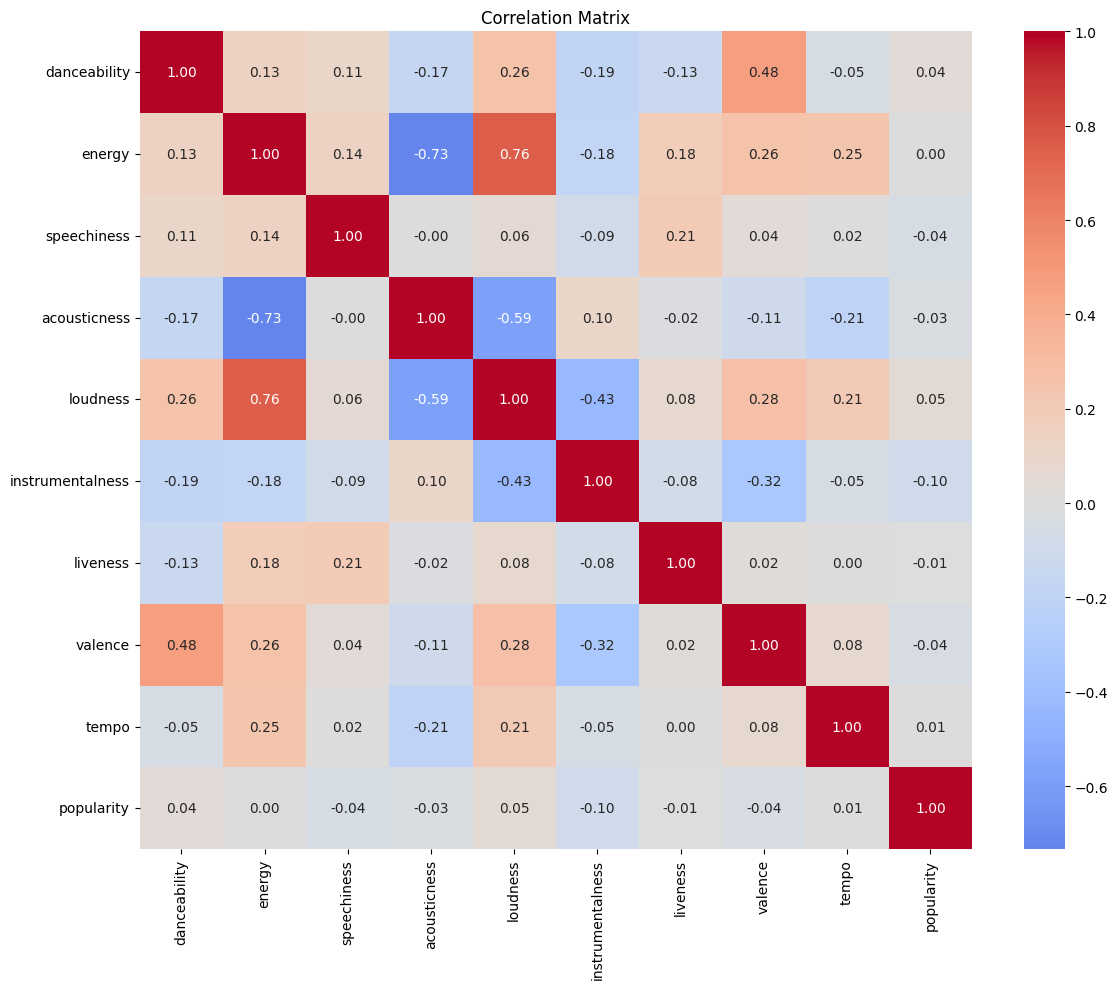

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[audio_features + ['popularity']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../report/images/02_corr.png', dpi=300)
plt.show()

В связи с отсутствием сильной линейной зависимости, а тажке тем, что некоторые аудио-фичи сильно корреклируют между собой, можно сделать выводы, что для определения нелинейных зависимостей помогут ансамблевые моделм

## 6. Визуализация зависимости аудио-фич от популярности

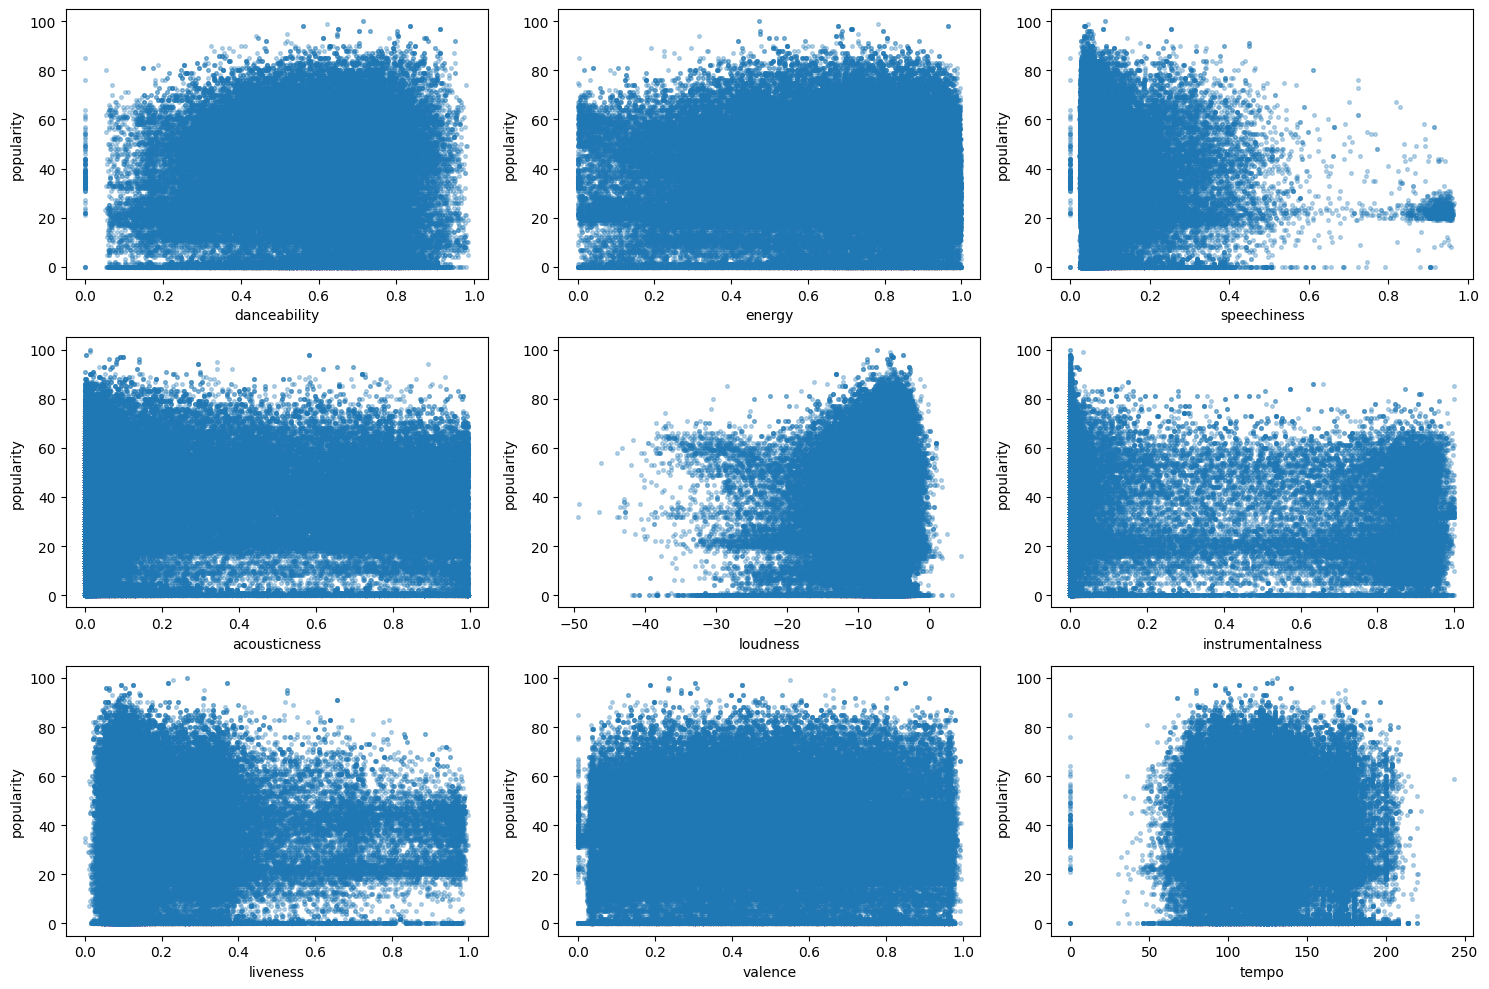

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()
for idx, feat in enumerate(audio_features):
    axes[idx].scatter(df[feat], df['popularity'], alpha=0.3, s=7)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('popularity')
plt.tight_layout()
plt.savefig('../report/images/03_feat.png', dpi=300)
plt.show()

Убедимся в выводах после анализа корреляционной матрицы за счёт этих графиков. Видно, что точки распределены хаотичны, а следовательно нет какой-то чёткой зависимости, очень высокий шум. Лучше всего себя покажут ансамблевые модели.

In [8]:
save_processed_data(df, DATA_PROCESSED)

Данные успешно сохранены по пути: ../data/processed/spotify_processed.csv
